In [1]:
import argparse
import os
import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
import PIL
from PIL import Image

from copy import deepcopy
from einops import rearrange
from types import SimpleNamespace

from diffusers import DDIMScheduler, AutoencoderKL
from torchvision.utils import save_image
from pytorch_lightning import seed_everything

import sys
from drag_pipeline import DragPipeline

from utils.drag_utils import drag_diffusion_update
from utils.attn_utils import register_attention_editor_diffusers, MutualSelfAttentionControl

import os
print(os.environ["LD_LIBRARY_PATH"])

/users/eleves-b/2024/yiming.chen/miniconda3/envs/drag/lib


In [ ]:
def preprocess_image(image,
                     device):
    image = torch.from_numpy(image).float() / 127.5 - 1 # [-1, 1]
    image = rearrange(image, "h w c -> 1 c h w")
    image = image.to(device)
    return image

# copy the run_drag function to here
def run_drag(source_image,
             # image_with_clicks,
             mask,
             prompt,
             points,
             inversion_strength,
             lam,
             latent_lr,
             unet_feature_idx,
             n_pix_step,
             model_path,
             vae_path,
             lora_path,
             start_step,
             start_layer,
             # save_dir="./results"
    ):
    # initialize model
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012,
                          beta_schedule="scaled_linear", clip_sample=False,
                          set_alpha_to_one=False, steps_offset=1)
    model = DragPipeline.from_pretrained(model_path, scheduler=scheduler).to(device)
    # call this function to override unet forward function,
    # so that intermediate features are returned after forward
    model.modify_unet_forward()

    # set vae
    if vae_path != "default":
        model.vae = AutoencoderKL.from_pretrained(
            vae_path
        ).to(model.vae.device, model.vae.dtype)

    # initialize parameters
    seed = 42 # random seed used by a lot of people for unknown reason
    seed_everything(seed)

    args = SimpleNamespace()
    args.prompt = prompt
    args.points = points
    args.n_inference_step = 50
    args.n_actual_inference_step = round(inversion_strength * args.n_inference_step)
    args.guidance_scale = 1.0

    args.unet_feature_idx = [unet_feature_idx]

    args.r_m = 1
    args.r_p = 3
    args.lam = lam

    args.lr = latent_lr
    args.n_pix_step = n_pix_step

    full_h, full_w = source_image.shape[:2]
    args.sup_res_h = int(0.5*full_h)
    args.sup_res_w = int(0.5*full_w)

    print(args)

    source_image = preprocess_image(source_image, device)
    # image_with_clicks = preprocess_image(image_with_clicks, device)

    # set lora
    if lora_path == "":
        print("applying default parameters")
        model.unet.set_default_attn_processor()
    else:
        print("applying lora: " + lora_path)
        model.unet.load_attn_procs(lora_path)

    # invert the source image
    # the latent code resolution is too small, only 64*64
    invert_code = model.invert(source_image,
                               prompt,
                               guidance_scale=args.guidance_scale,
                               num_inference_steps=args.n_inference_step,
                               num_actual_inference_steps=args.n_actual_inference_step)

    mask = torch.from_numpy(mask).float()
    # mask[mask > 0.0] = 1.0
    mask = rearrange(mask, "h w -> 1 1 h w").cuda()
    mask = F.interpolate(mask, (args.sup_res_h, args.sup_res_w), mode="nearest")

    handle_points = []
    target_points = []
    # here, the point is in x,y coordinate
    for idx, point in enumerate(points):
        cur_point = torch.tensor([point[1]/full_h*args.sup_res_h, point[0]/full_w*args.sup_res_w])
        cur_point = torch.round(cur_point)
        if idx % 2 == 0:
            handle_points.append(cur_point)
        else:
            target_points.append(cur_point)
    print('handle points:', handle_points)
    print('target points:', target_points)

    init_code = invert_code
    init_code_orig = deepcopy(init_code)
    model.scheduler.set_timesteps(args.n_inference_step)
    t = model.scheduler.timesteps[args.n_inference_step - args.n_actual_inference_step]

    # feature shape: [1280,16,16], [1280,32,32], [640,64,64], [320,64,64]
    # update according to the given supervision
    updated_init_code = drag_diffusion_update(model, init_code,
        None, t, handle_points, target_points, mask, args)

    # hijack the attention module
    # inject the reference branch to guide the generation
    editor = MutualSelfAttentionControl(start_step=start_step,
                                        start_layer=start_layer,
                                        total_steps=args.n_inference_step,
                                        guidance_scale=args.guidance_scale)
    if lora_path == "":
        register_attention_editor_diffusers(model, editor, attn_processor='attn_proc')
    else:
        register_attention_editor_diffusers(model, editor, attn_processor='lora_attn_proc')

    # inference the synthesized image
    gen_image = model(
        prompt=args.prompt,
        batch_size=2,
        latents=torch.cat([init_code_orig, updated_init_code], dim=0),
        guidance_scale=args.guidance_scale,
        num_inference_steps=args.n_inference_step,
        num_actual_inference_steps=args.n_actual_inference_step
        )[1].unsqueeze(dim=0)

    # resize gen_image into the size of source_image
    # we do this because shape of gen_image will be rounded to multipliers of 8
    gen_image = F.interpolate(gen_image, (full_h, full_w), mode='bilinear')

    # save the original image, user editing instructions, synthesized image
    # save_result = torch.cat([
    #     source_image * 0.5 + 0.5,
    #     torch.ones((1,3,full_h,25)).cuda(),
    #     image_with_clicks * 0.5 + 0.5,
    #     torch.ones((1,3,full_h,25)).cuda(),
    #     gen_image[0:1]
    # ], dim=-1)

    # if not os.path.isdir(save_dir):
    #     os.mkdir(save_dir)
    # save_prefix = datetime.datetime.now().strftime("%Y-%m-%d-%H%M-%S")
    # save_image(save_result, os.path.join(save_dir, save_prefix + '.png'))

    out_image = gen_image.cpu().permute(0, 2, 3, 1).numpy()[0]
    out_image = (out_image * 255).astype(np.uint8)
    return out_image

In [3]:
import numpy as np
from PIL import Image

img = Image.open("assets/ferriswheel.png").convert("RGB")
img_np = np.array(img)
H, W, _ = img_np.shape

mask = np.zeros((H, W), dtype=np.uint8) 

In [4]:
from ipycanvas import Canvas
from IPython.display import display
import ipywidgets as widgets

canvas = Canvas(width=W, height=H)
canvas.put_image_data(img_np, 0, 0)

brush_radius = 40
drawing = False

def on_mouse_down(x, y):
    global drawing
    drawing = True

def on_mouse_up(x, y):
    global drawing
    drawing = False

def on_mouse_move(x, y):
    if not drawing:
        return
    canvas.fill_style = "rgba(255, 255, 255, 0.4)"
    canvas.fill_circle(x, y, brush_radius)
    yy, xx = np.ogrid[:H, :W]
    circle = (xx - x) ** 2 + (yy - y) ** 2 <= brush_radius ** 2
    mask[circle] = 1

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_up(on_mouse_up)
canvas.on_mouse_move(on_mouse_move)

def clear_mask(b=None):
    global mask
    mask[:] = 0
    canvas.clear()
    canvas.put_image_data(img_np, 0, 0)
        
clear_btn = widgets.Button(description="Clear Mask")
clear_btn.on_click(clear_mask)
display(canvas, clear_btn)


Canvas(height=400, width=600)

Button(description='Clear Mask', style=ButtonStyle())

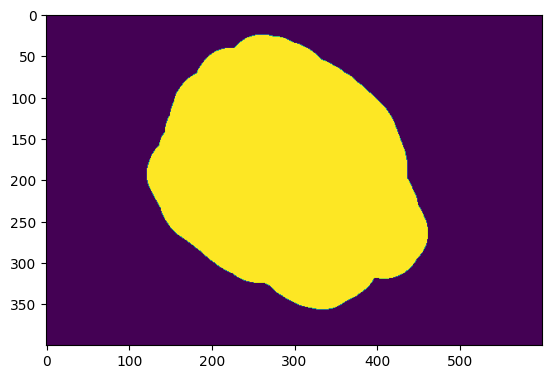

In [5]:
import matplotlib.pyplot as plt
plt.imshow(mask)

In [7]:
from utils.lora_utils import train_lora
import tqdm

prompt = "a photo of a ferris whell at sunset"

model_path = "runwayml/stable-diffusion-v1-5"
vae_path = "default"
lora_steps = 80
inv_strength = 0.7
lora_lr = 1e-4
lora_rank = 16
lora_batch_size = 4

lora_save_dir = "lora_tmp/ferris_wheel/"

# model_path in [
#     "runwayml/stable-diffusion-v1-5",
#     "gsdf/Counterfeit-V2.5",
#     "stablediffusionapi/anything-v5",
#     "SG161222/Realistic_Vision_V2.0",
# ]
# vae_path in ["default", "stabilityai/sd-vae-ft-mse"]

train_lora(
    img_np,
    prompt,
    model_path,
    vae_path,
    lora_save_dir,
    lora_steps,
    lora_lr,
    lora_batch_size,
    lora_rank,
    progress=tqdm
)

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.

















































































training LoRA: 100%|██████████| 80/80 [00:42<00:00,  1.89it/s]


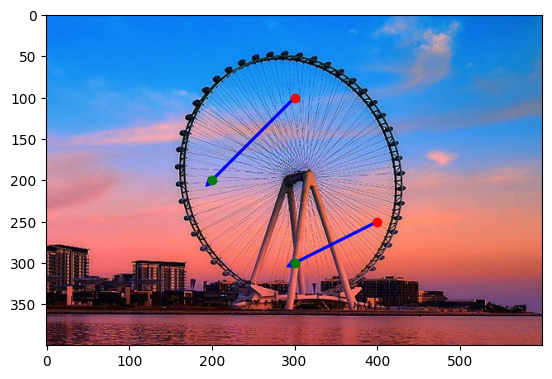

In [23]:
draw_points = [
    (300, 100), # handle point (x,y)
    (200, 200), # target point (x,y)
    (400, 250), # handle point (x,y)
    (300, 300)  # target point (x,y)
]

# Visulize the points
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.imshow(img_np)

for idx, point in enumerate(draw_points):
    x, y = point
    ax.plot(x, y, 'ro' if idx % 2 == 0 else 'go')
    if idx % 2 == 1:
        hx, hy = draw_points[idx - 1]
        ax.arrow( hx, hy, x - hx, y - hy, head_width=10, head_length=10, fc='blue', ec='blue', width=2)

plt.show()

In [26]:
lam = 0.1
latent_lr = 0.01
unet_feature_idx = 3
n_pix_step = 80
start_step = 0
start_layer = 10

out_image = run_drag(
    img_np,
    # image_with_clicks=img_with_clicks_np,
    mask,
    prompt,
    draw_points,
    inv_strength,
    lam,
    latent_lr,
    unet_feature_idx,
    n_pix_step,
    model_path,
    vae_path,
    lora_save_dir,
    start_step=10,
    start_layer=4,
    # save_dir="./results"
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
Global seed set to 42


namespace(guidance_scale=1.0, lam=0.1, lr=0.01, n_actual_inference_step=35, n_inference_step=50, n_pix_step=80, points=[(300, 100), (200, 200), (400, 250), (300, 300)], prompt='a photo of a ferris whell at sunset', r_m=1, r_p=3, sup_res_h=200, sup_res_w=300, unet_feature_idx=[3])
applying lora: lora_tmp/ferris_wheel/
latents shape:  torch.Size([1, 4, 50, 75])
Valid timesteps:  tensor([  1,  21,  41,  61,  81, 101, 121, 141, 161, 181, 201, 221, 241, 261,
        281, 301, 321, 341, 361, 381, 401, 421, 441, 461, 481, 501, 521, 541,
        561, 581, 601, 621, 641, 661, 681, 701, 721, 741, 761, 781, 801, 821,
        841, 861, 881, 901, 921, 941, 961, 981])


DDIM Inversion: 100%|██████████| 50/50 [00:02<00:00, 17.72it/s]


handle points: [tensor([ 50., 150.]), tensor([125., 200.])]
target points: [tensor([100., 100.]), tensor([150., 150.])]
loss total=4.823048
new handle points [tensor([ 50., 150.]), tensor([125., 200.])]
loss total=14.780893
new handle points [tensor([ 50., 149.]), tensor([125., 200.])]
loss total=14.275146
new handle points [tensor([ 51., 149.]), tensor([125., 200.])]
loss total=10.362741
new handle points [tensor([ 51., 149.]), tensor([125., 199.])]
loss total=5.991834
new handle points [tensor([ 51., 149.]), tensor([125., 199.])]
loss total=8.910503
new handle points [tensor([ 51., 149.]), tensor([125., 199.])]
loss total=9.883629
new handle points [tensor([ 51., 149.]), tensor([125., 199.])]
loss total=9.139027
new handle points [tensor([ 51., 148.]), tensor([125., 199.])]
loss total=8.672635
new handle points [tensor([ 51., 148.]), tensor([125., 199.])]
loss total=7.867118
new handle points [tensor([ 52., 148.]), tensor([125., 199.])]
loss total=6.838422
new handle points [tensor([

DDIM Sampler: 100%|██████████| 50/50 [00:04<00:00, 10.29it/s] 


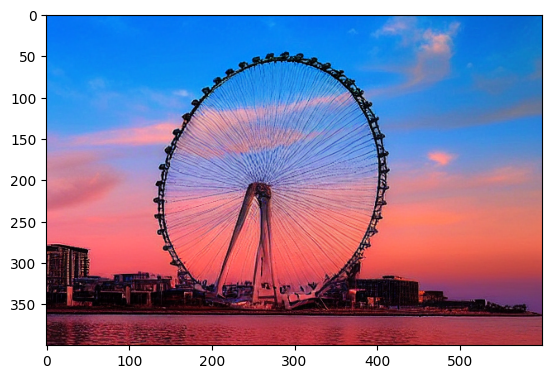

In [30]:
plt.imshow(out_image)